In [ ]:
from typing import TypedDict, Literal
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt


# 1. State-nya cuma butuh field sederhana
class State(TypedDict):
    action: str
    status: str


# 2. Node yang minta approval manusia
def ask_approval(state: State) -> Command[Literal["do_action", "cancel"]]:
    decision = interrupt(f"Setuju untuk melakukan: {state['action']}?")  # True/False dari manusia

    if decision:
        return Command(goto="do_action")
    else:
        return Command(goto="cancel")


# 3. Node kalau disetujui
def do_action(state: State):
    print(f"Menjalankan aksi: {state['action']}")
    return {"status": "dijalankan"}


# 4. Node kalau ditolak
def cancel(state: State):
    print("Aksi dibatalkan")
    return {"status": "dibatalkan"}



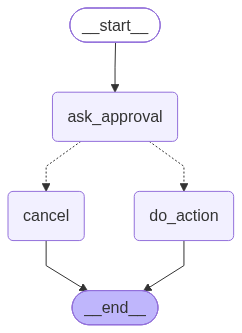

In [3]:

# 5. Bangun graph
builder = StateGraph(State)
builder.add_node("ask_approval", ask_approval)
builder.add_node("do_action", do_action)
builder.add_node("cancel", cancel)

builder.add_edge(START, "ask_approval")
builder.add_edge("do_action", END)
builder.add_edge("cancel", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)
graph

In [14]:
# ============================================
# CARA JALANKAN
# ============================================

config = {"configurable": {"thread_id": "1"}}

# Jalankan pertama kali — akan berhenti di interrupt()
result = graph.invoke({"action": "hapus semua data user", "status": "pending"}, config=config)

print(result["__interrupt__"])
# -> (Interrupt(value='Setuju untuk melakukan: hapus semua data user?'),)


[Interrupt(value='Setuju untuk melakukan: hapus semua data user?', id='6ef05464071ac53f36d4eb97c9894916')]


In [15]:
# Manusia setuju -> resume dengan True
final = graph.invoke(Command(resume=True), config=config)
print(final["status"])  # -> "dijalankan"

Menjalankan aksi: hapus semua data user
dijalankan


In [12]:
# Kalau mau reject, tinggal:
final = graph.invoke(Command(resume=False), config=config)  # -> "dibatalkan"
print(final["status"])  # -> "dibatalkan"

Aksi dibatalkan
dibatalkan
